In [10]:
import kagglehub
import os
import pandas as pd
import glob
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Download latest version of dataset
path = kagglehub.dataset_download("desalegngeb/students-exam-scores")

# Show dataset path and files inside
print("Path to dataset files:", path)
print("Files in dataset:", os.listdir(path))
# find any CSV under the dataset path (including subfolders)
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
if not csv_files:
    raise FileNotFoundError(f"No CSV file found under {path}")
csv_path = csv_files[0]
print("Using CSV file:", csv_path)

df = pd.read_csv(csv_path)




Path to dataset files: C:\Users\naman yadav\.cache\kagglehub\datasets\desalegngeb\students-exam-scores\versions\2
Files in dataset: ['Expanded_data_with_more_features.csv', 'Original_data_with_more_rows.csv']
Using CSV file: C:\Users\naman yadav\.cache\kagglehub\datasets\desalegngeb\students-exam-scores\versions\2\Expanded_data_with_more_features.csv


In [66]:
df.rename(columns={
    'EthnicGroup' : 'Ethnic_Group',
    'ParentEduc' : 'Parental_education',
    'TestPrep' : 'Test_preparation',
    'PracticeSport' : 'Practice_Sport',
    'WklyStudyHours' : 'Weekly_study_Hours',
    'MathScore' : 'Math_Score',
    'ReadingScore' : 'Reading_Score',
    'WritingScore' : 'Writing_Score'
}, inplace=True)


In [8]:
df.shape

(30641, 15)

In [11]:
df.describe()

,Unnamed: 0,NrSiblings,MathScore,ReadingScore,WritingScore
count,30641.000000,29069.000000,30641.000000,30641.000000,30641.000000
mean,499.556607,2.145894,66.558402,69.377533,68.418622
std,288.747894,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,0.000000,10.000000,4.000000
25%,249.000000,1.000000,56.000000,59.000000,58.000000
50%,500.000000,2.000000,67.000000,70.000000,69.000000
75%,750.000000,3.000000,78.000000,80.000000,79.000000
max,999.000000,7.000000,100.000000,100.000000,100.000000


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  str    
 2   EthnicGroup          28801 non-null  str    
 3   ParentEduc           28796 non-null  str    
 4   LunchType            30641 non-null  str    
 5   TestPrep             28811 non-null  str    
 6   ParentMaritalStatus  29451 non-null  str    
 7   PracticeSport        30010 non-null  str    
 8   IsFirstChild         29737 non-null  str    
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  str    
 11  WklyStudyHours       29686 non-null  str    
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), str(10)
memory usage: 

In [14]:
df.tail()

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
30636,816,female,group D,high school,standard,none,single,sometimes,no,2.0,school_bus,5 - 10,59,61,65
30637,890,male,group E,high school,standard,none,single,regularly,no,1.0,private,5 - 10,58,53,51
30638,911,female,NaN,high school,free/reduced,completed,married,sometimes,no,1.0,private,5 - 10,61,70,67
30639,934,female,group D,associate's degree,standard,completed,married,regularly,no,3.0,school_bus,5 - 10,82,90,93
30640,960,male,group B,some college,standard,none,married,never,no,1.0,school_bus,5 - 10,64,60,58


In [22]:
df = df.drop(columns=['Unnamed: 0', 'LunchType'], errors='ignore')



In [27]:
df.isnull().sum()

Gender                    0
EthnicGroup            1840
ParentEduc             1845
TestPrep               1830
ParentMaritalStatus    1190
PracticeSport           631
IsFirstChild            904
NrSiblings             1572
TransportMeans         3134
WklyStudyHours          955
MathScore                 0
ReadingScore              0
WritingScore              0
dtype: int64

In [25]:
df.isnull().sum().sum()

np.int64(13901)

In [26]:
df[df.isnull().any(axis=1)]


,Gender,EthnicGroup,ParentEduc,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
3,male,group A,associate's degree,none,married,never,no,1.0,NaN,5 - 10,45,56,42
9,female,group B,high school,none,married,regularly,yes,NaN,private,< 5,37,59,50
10,male,group C,associate's degree,none,NaN,sometimes,yes,1.0,private,5 - 10,58,54,52
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30627,female,group A,high school,completed,married,never,no,NaN,school_bus,> 10,58,77,82
30628,female,group B,NaN,none,single,sometimes,no,1.0,school_bus,5 - 10,55,63,63
30629,female,group D,associate's degree,completed,married,sometimes,no,2.0,school_bus,NaN,67,63,72
30634,male,group A,associate's degree,completed,NaN,sometimes,no,2.0,school_bus,5 - 10,65,60,60


In [ ]:
data = df["EthnicGroup"].fillna("Unknown", inplace=True)
print(data)


In [32]:
data

0        Unknown
1        group C
2        group B
3        group A
4        group C
          ...   
30636    group D
30637    group E
30638    Unknown
30639    group D
30640    group B
Name: EthnicGroup, Length: 30641, dtype: str

In [44]:
df['NrSiblings'].dtype

dtype('float64')

In [47]:
df['NrSiblings'] = df['NrSiblings'].astype('Int64')
df['NrSiblings'].dtype

Int64Dtype()

In [50]:
df['WklyStudyHours'].value_counts()

WklyStudyHours
5 - 10    16246
< 5        8238
> 10       5202
Name: count, dtype: int64

In [53]:
df['WklyStudyHours'] = df['WklyStudyHours'].replace({ 
    '5 - 10' : 'btw 5 to 10 hours',
    '< 5': 'less than 5 hours',
    '> 10': 'more than 10 hours'
})


In [55]:
df['Gender'] = df['Gender'].replace({
    'male': 'MALE',
    'female': 'FEMALE',
})

In [58]:
df['Total_Score'] = df['MathScore'] + df['ReadingScore'] + df['WritingScore']

In [60]:
df['Result']=df['Total_Score'].apply(lambda x : 'Pass' if x >150 else 'Fail')

In [64]:
df = df.drop(columns=['IsFirstChild', 'NrSiblings','TransportMeans', 'ParentMaritalStatus'], errors='ignore')

In [72]:
df['Test_preparation'] = df['Test_preparation'].str.strip().str.lower()
df['Test_preparation'].replace({'none': 'Not Prepared', 'completed': 'Prepared'}, inplace=True)


C:\Users\naman yadav\AppData\Local\Temp\ipykernel_3904\3329970719.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Test_preparation'].replace({'none': 'Not Prepared', 'completed': 'Prepared'}, inplace=True)


0        Not Prepared
1                 NaN
2        Not Prepared
3        Not Prepared
4        Not Prepared
             ...     
30636    Not Prepared
30637    Not Prepared
30638        Prepared
30639        Prepared
30640    Not Prepared
Name: Test_preparation, Length: 30641, dtype: str

In [68]:
df['Test_preparation'].value_counts()

Test_preparation
none         18856
completed     9955
Name: count, dtype: int64

In [73]:
df['Test_preparation'] = df['Test_preparation'].replace({'none': 'Not Prepared', 'completed': 'Prepared'})


In [74]:
df['Practice_Sport'] = df['Practice_Sport'].str.strip().str.lower()

In [75]:
print(df.columns)

Index(['Gender', 'Ethnic_Group', 'Parental_education', 'Test_preparation',
       'Practice_Sport', 'Weekly_study_Hours', 'Math_Score', 'Reading_Score',
       'Writing_Score', 'Total_Score', 'Result'],
      dtype='str')


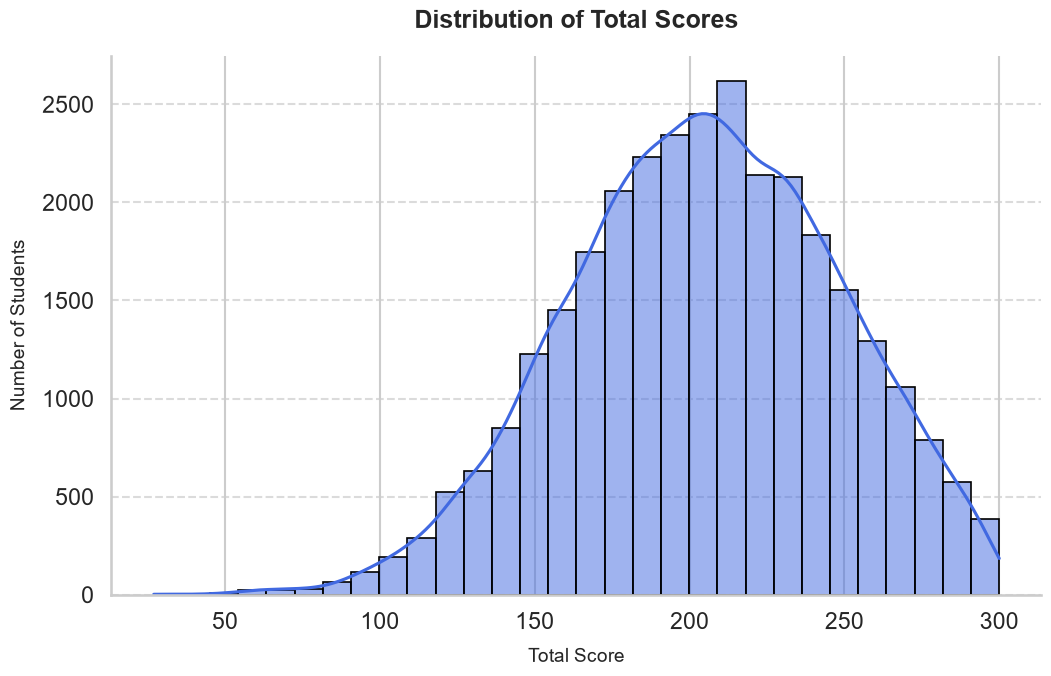

In [79]:


sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(12, 7))
sns.histplot(
    df['Total_Score'],
    bins=30,
    kde=True,
    color='royalblue',
    edgecolor='black',
    linewidth=1.2
)

plt.title('Distribution of Total Scores', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Total Score', fontsize=14, labelpad=10)
plt.ylabel('Number of Students', fontsize=14, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()
plt.show()


In [89]:
df['Parental_education'].value_counts()
df['Parental_education'].value_counts()
df['Parental_education'].unique()

<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school',
                  nan]
Length: 7, dtype: str

Text(0.5, 1.0, 'Distribution of the test scores')

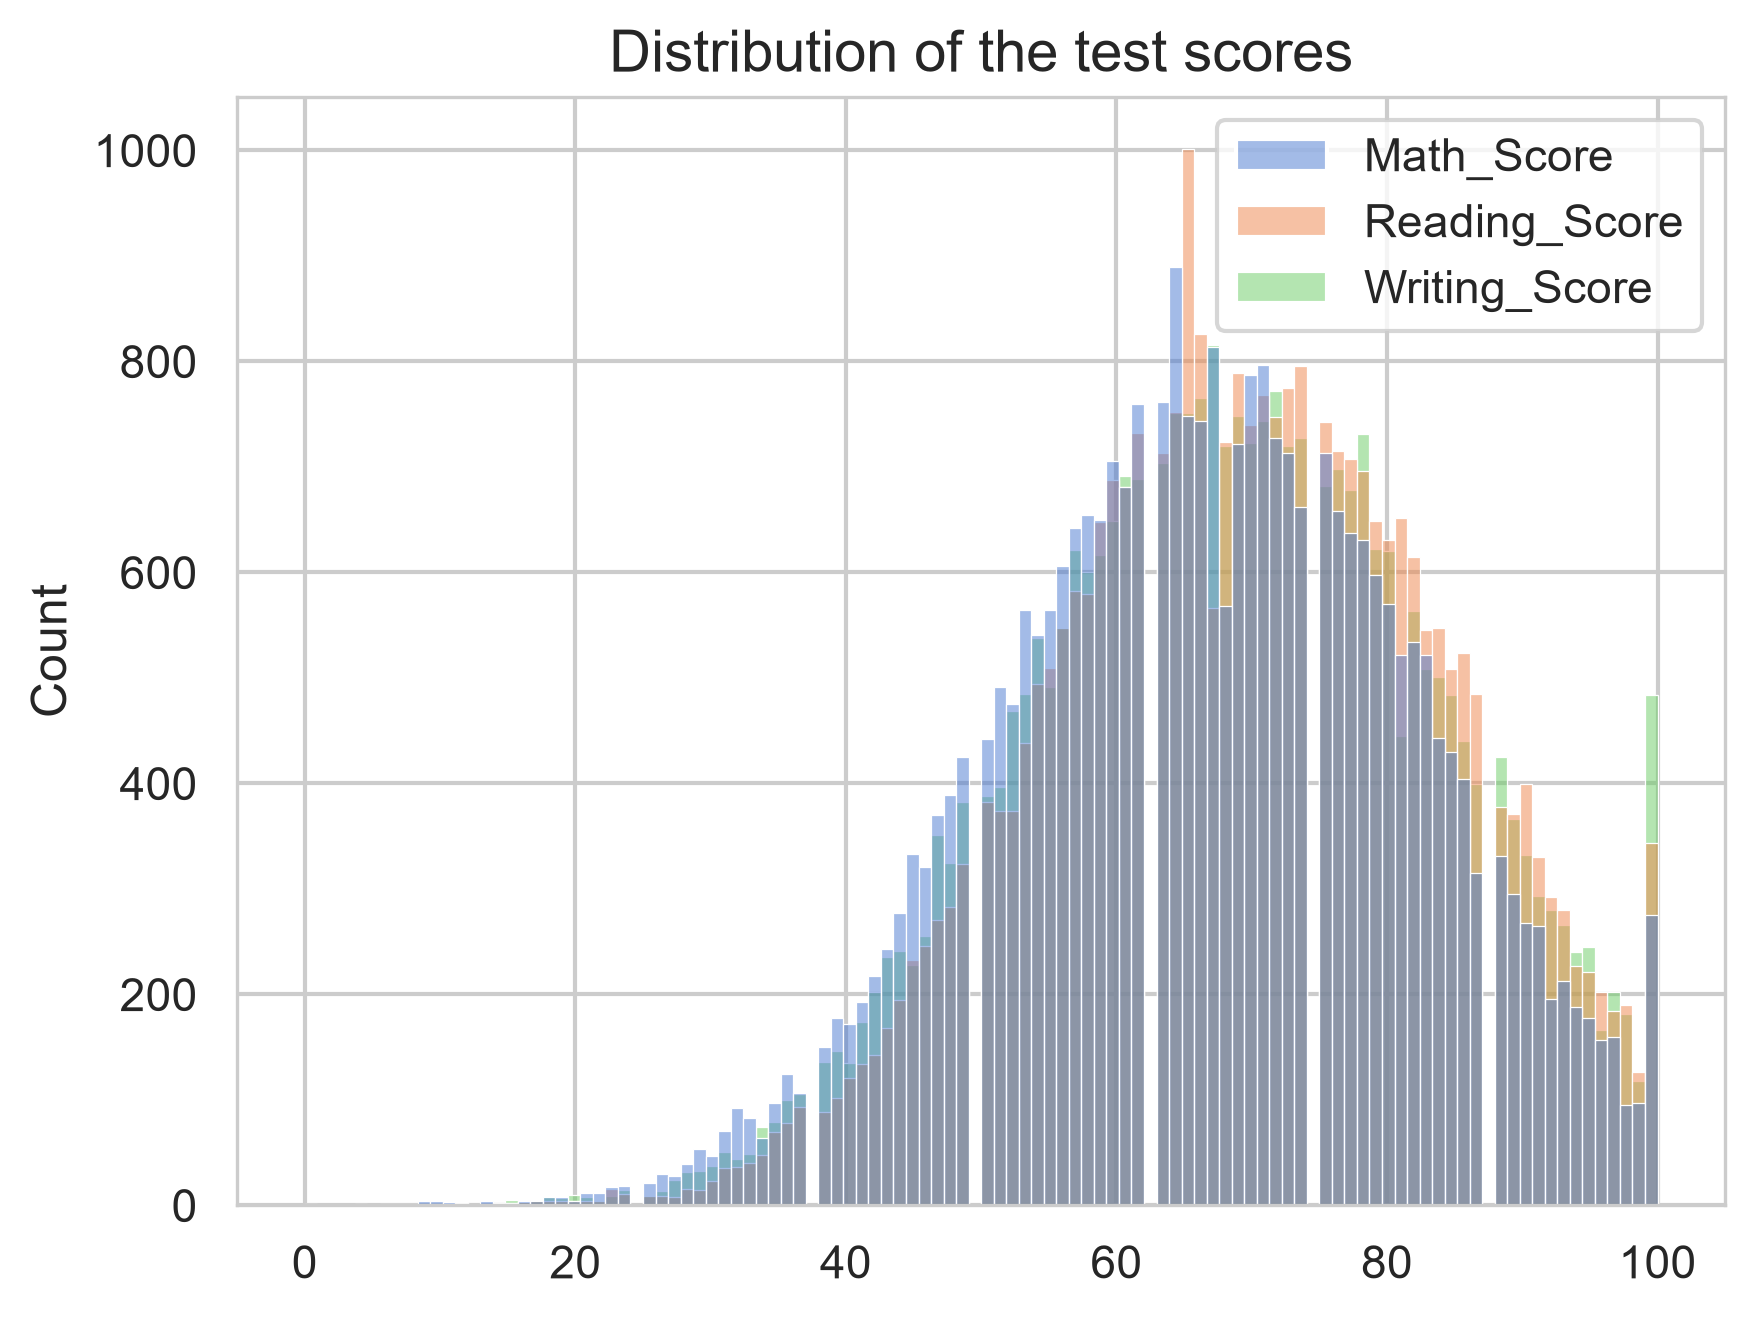

In [95]:
sns.histplot(df[['Math_Score', 'Reading_Score','Writing_Score']])
plt.title('Distribution of the test scores')

In [93]:
df.columns

Index(['Gender', 'Ethnic_Group', 'Parental_education', 'Test_preparation',
       'Practice_Sport', 'Weekly_study_Hours', 'Math_Score', 'Reading_Score',
       'Writing_Score', 'Total_Score', 'Result'],
      dtype='str')

In [96]:
df.groupby(['Gender'])[['Math_Score','Reading_Score',
       'Writing_Score', 'Total_Score',]].agg(np.mean)

,Math_Score,Reading_Score,Writing_Score,Total_Score
Gender,,,,
FEMALE,64.080654,72.853216,72.856457,209.790327
MALE,69.069856,65.854571,63.920418,198.844845


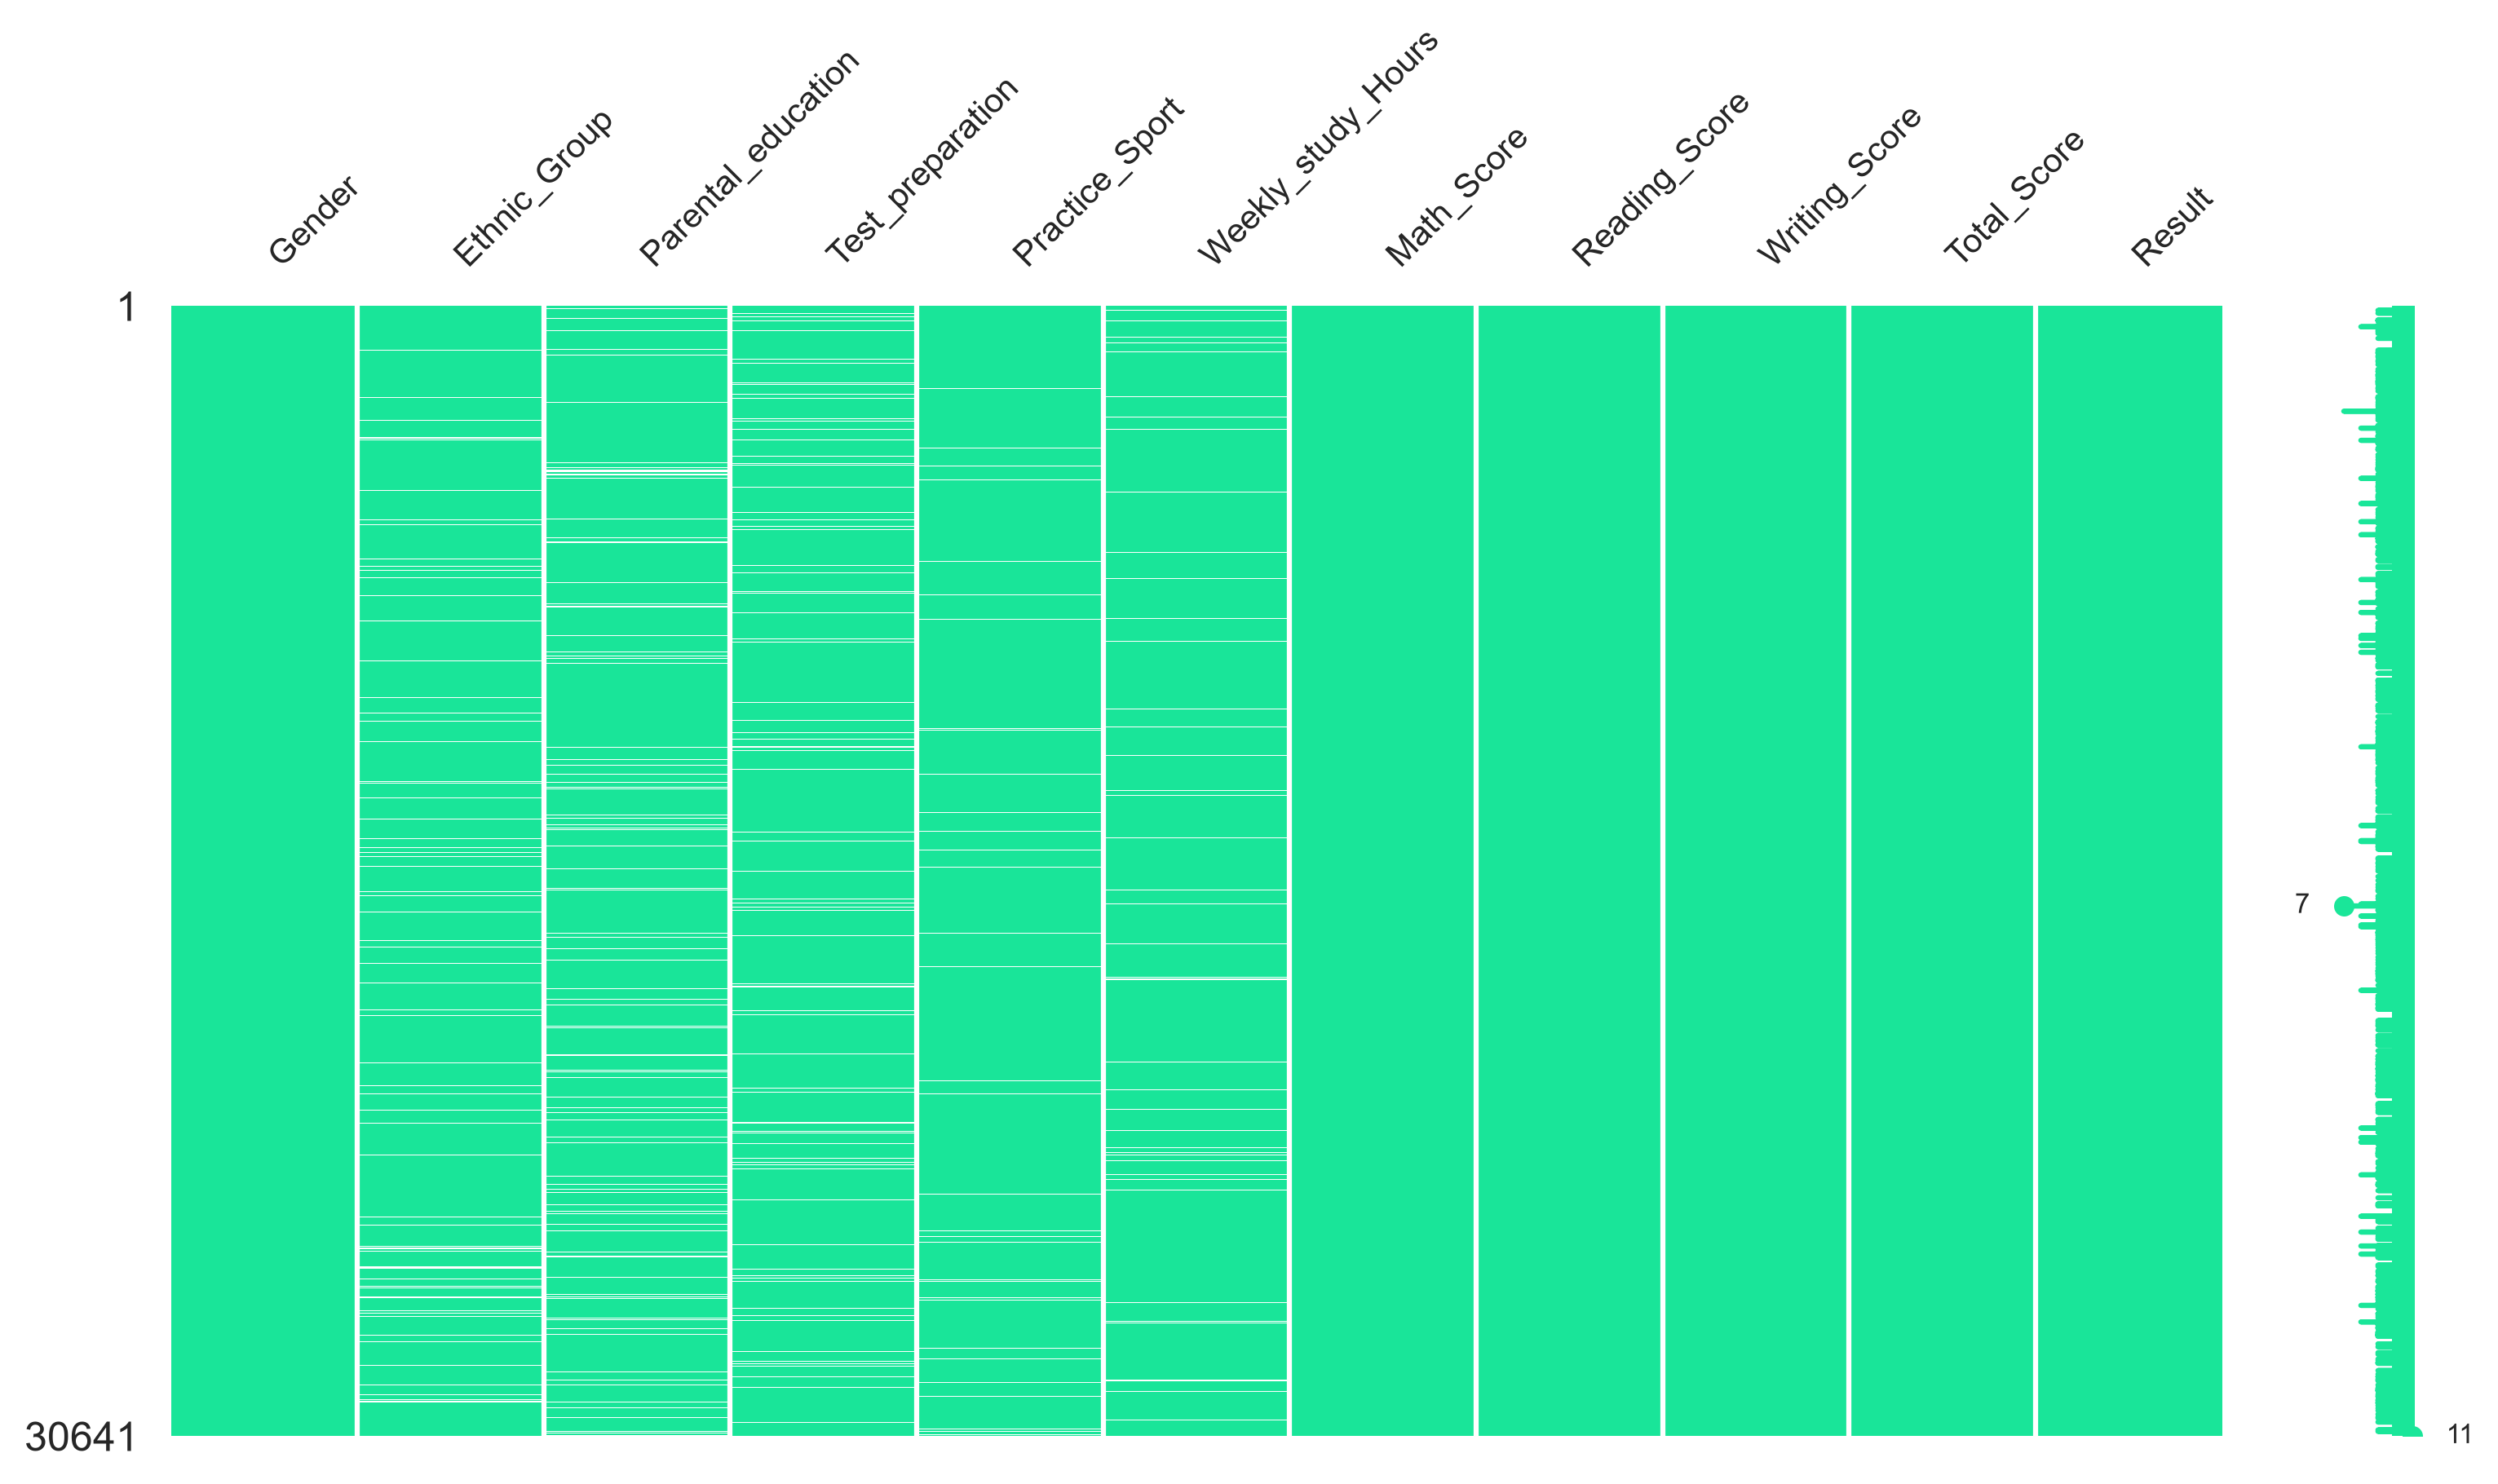

In [99]:
import subprocess
subprocess.check_call(['pip', 'install', 'missingno'])
import missingno as msno

data_extended = df.copy()
msno.matrix(data_extended,
           figsize=(12, 6),
           color=(0.1, 0.9, 0.6),
           fontsize=10)
plt.show();

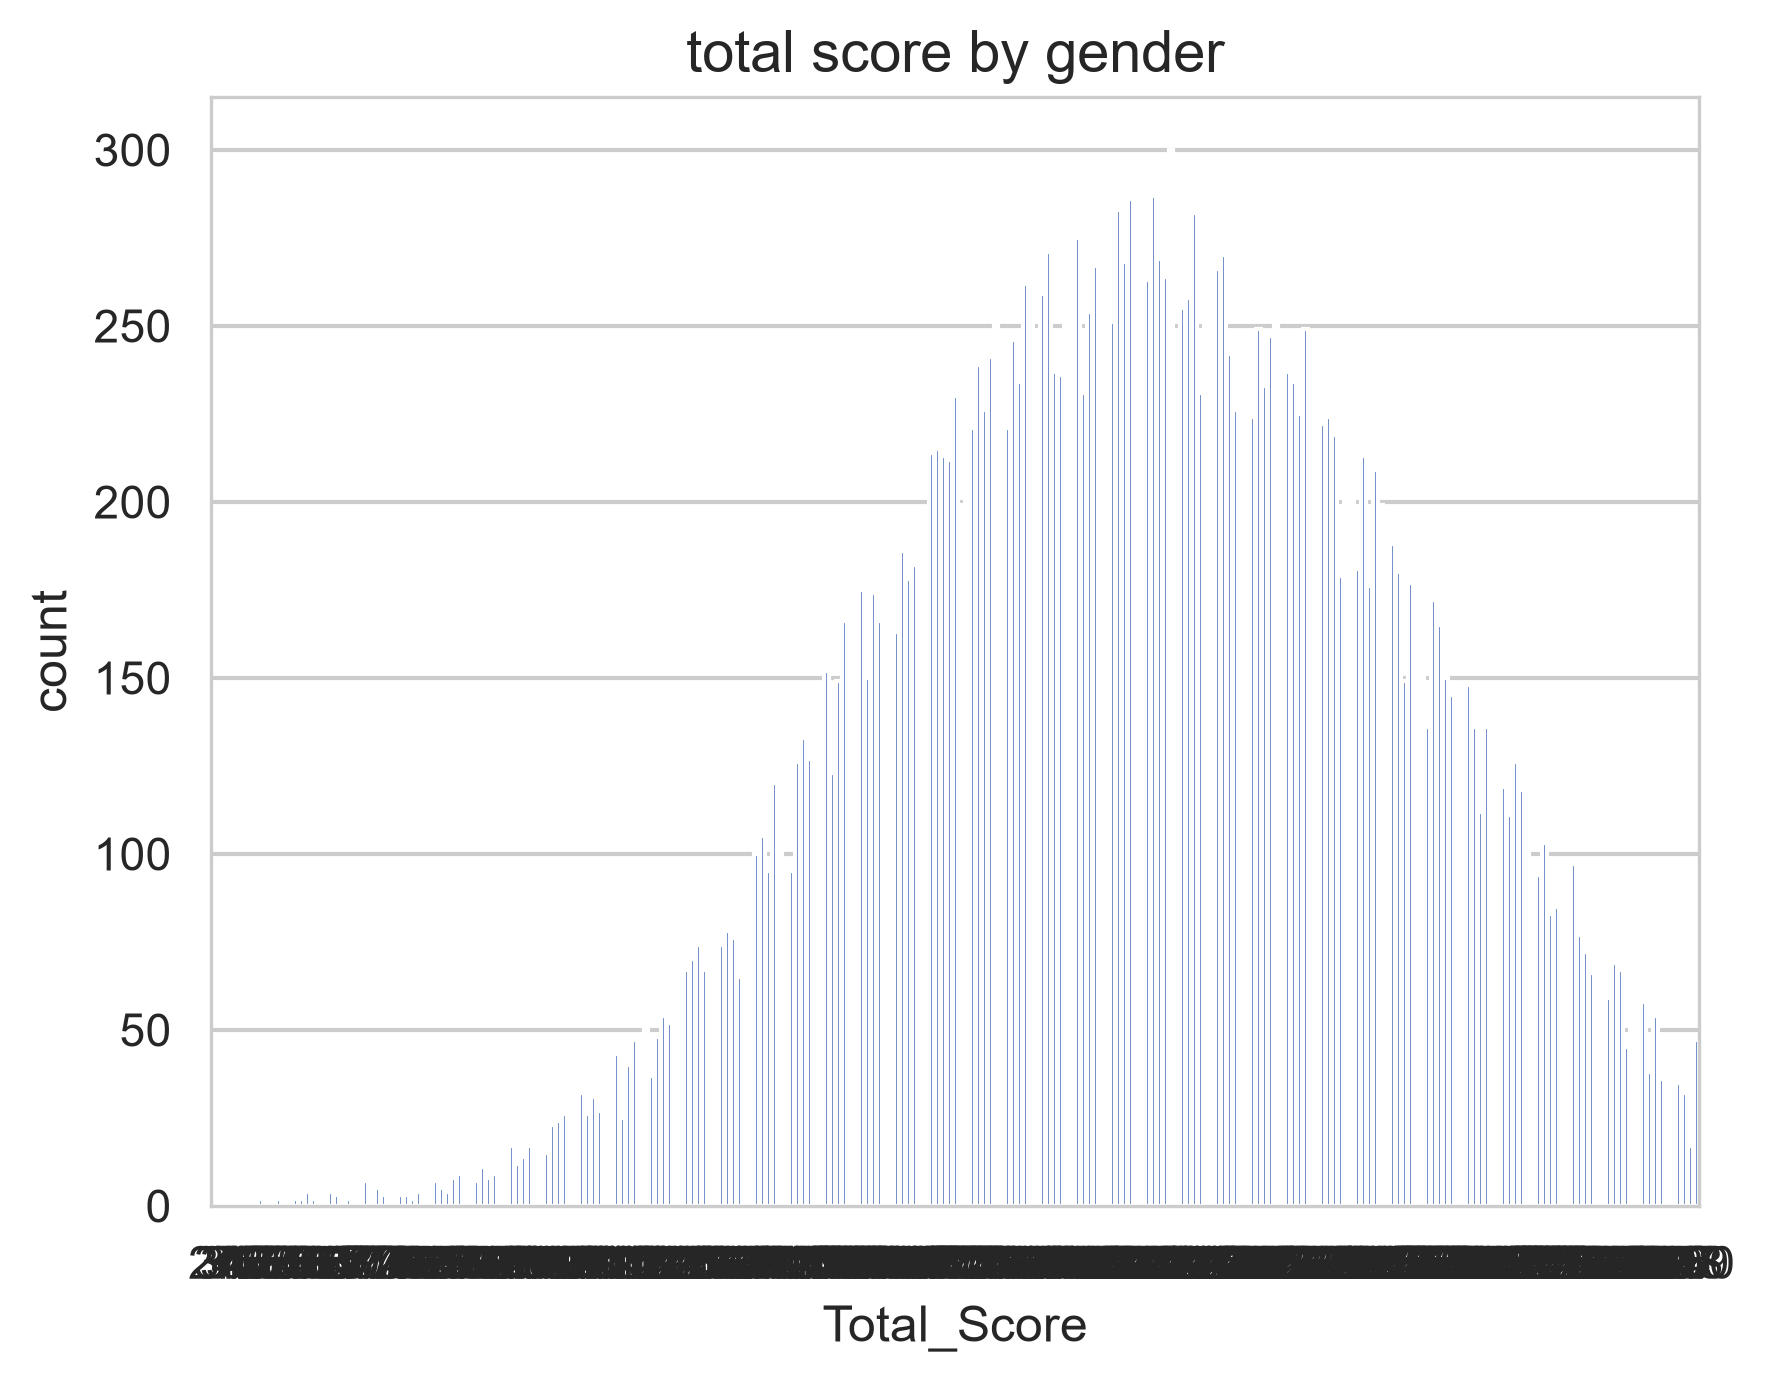

In [104]:
sns.countplot( x='Total_Score', data=df)
plt.title("total score by gender")
plt.show()